In [142]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

import os 
import sys 

from get_train_test import TrainTestBuilder
from statistical_functions import run_logit_model
from visual_functions import plot_model_metrics, expected_calibration_error
from utils import save_results

import joblib

In [227]:

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-07.csv'
df_model = pd.read_csv(fp)

df_model['math_red'] = df_model['math_red'].astype('category')
df_model['math_blue'] = df_model['math_blue'].astype('category')
df_model['elo_pred'] = df_model['elo_pred'].astype('category')

non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'proba_fair_close1_red','proba_fair_close1_blue','proba_fair_close2_red','proba_fair_close2_blue',
    'performance_bonus_winner', 'fight_otn_bonus', 'close1_blue','close1_red', 'close2_blue', 'close2_red'
] 


# selected_feats = [
#                   'proba_fair_open_diff', 'reach_diff', 
#                   'td_landed_pm_red', 'td_landed_pm_blue', 'ratio_control_red', 'ratio_control_blue', 'ratio_td_red', 'ratio_td_blue', 
#                   'adjusted_sig_str_blue', 'adjusted_sig_str_red', 
#                   'sig_str_absorbed_total_diff', 
#                   'sig_str_defense_pct_diff', 'ratio_sig_str_red', 'ratio_sig_str_blue', 'kd_pm_diff', 
                    
#                   'win_pct_red', 'win_pct_blue', 
#                   'win_streak_diff', 'lose_streak_diff',
#                   'elo_red', 'elo_blue', 'age_red', 'age_blue',
#                   ]



# selected_feats = [
#                   'proba_fair_open_diff', 'reach_diff', 
                  
#                   'sub_pct_red', 'sub_pct_blue',
#                   'td_landed_pm_red', 'td_landed_pm_blue', 'ratio_control_red', 'ratio_control_blue', 'ratio_td_red', 'ratio_td_blue', 
                  
#                   'sig_str_absorbed_pm_red', 'sig_str_absorbed_pm_blue', 
#                   'sig_str_accuracy_pct_red', 'sig_str_accuracy_pct_blue',
#                   'ratio_sig_str_red', 'ratio_sig_str_blue', 'sig_str_defense_pct_red', 'sig_str_defense_pct_blue',
#                   'kd_pm_diff', 
#                   'sig_str_absorbed_total_red',  'sig_str_absorbed_total_blue', 
                    
#                   'win_pct_red', 'win_pct_blue',
#                   'win_streak_diff', 'lose_streak_diff',
#                   'elo_red', 'elo_blue', 'elo_pred', 'age_red', 'age_blue'
#                   ]


selected_feats = [
                  'proba_fair_open_diff', 'reach_diff', 
                  
                  'sub_att_pm_red', 'sub_att_pm_blue',
                  'ratio_control_diff',

                  'td_landed_pm_diff',  
                  'ratio_td_diff', 
                  'adjusted_td_red', 'adjusted_td_blue',

                  'sig_str_absorbed_total_diff', 
                  'sig_str_accuracy_pct_diff',
                  'sig_str_defense_pct_diff',
                  'adjusted_sig_str_blue', 'adjusted_sig_str_red', 
                  
                  'win_pct_red', 'win_pct_blue',
                  'win_streak_diff', 'lose_streak_diff',
                  'elo_red', 'elo_blue', 'elo_pred', 'age_red', 'age_blue',
                  ]



outlier_dict = None

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(selected_feats, outlier_dict=outlier_dict)


joblib.dump(scaler_open, fr"C:\Users\jcmar\my_files\SportsBetting\data\saved_models\scaler_open.pkl")



Filtered: kept 6650 rows from 2010-02-26 onward.
PREPARE SHAPE: (4256, 297)
MODEL SHAPE: (4177, 297)
Categorical columns: ['elo_pred']
Numerical columns: ['proba_fair_open_diff', 'reach_diff', 'sub_att_pm_red', 'sub_att_pm_blue', 'ratio_control_diff', 'td_landed_pm_diff', 'ratio_td_diff', 'adjusted_td_red', 'adjusted_td_blue', 'sig_str_absorbed_total_diff', 'sig_str_accuracy_pct_diff', 'sig_str_defense_pct_diff', 'adjusted_sig_str_blue', 'adjusted_sig_str_red', 'win_pct_red', 'win_pct_blue', 'win_streak_diff', 'lose_streak_diff', 'elo_red', 'elo_blue', 'age_red', 'age_blue']


['C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\scaler_open.pkl']

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6234917668656735
            Iterations: 86
            Function evaluations: 86
            Gradient evaluations: 86
                        feature       VIF
0                 ratio_td_diff  3.511558
1             td_landed_pm_diff  3.327548
2                       elo_red  3.033169
3                      elo_blue  2.947007
4                  win_pct_blue  2.177318
5            ratio_control_diff  2.151901
6                   win_pct_red  2.090682
7     sig_str_accuracy_pct_diff  1.877534
8      sig_str_defense_pct_diff  1.797860
9              adjusted_td_blue  1.706311
10              adjusted_td_red  1.618330
11  sig_str_absorbed_total_diff  1.565595
12              win_streak_diff  1.426140
13         proba_fair_open_diff  1.409758
14                      age_red  1.365894
15             lose_streak_diff  1.284900
16                     elo_pred  1.278249
17         adjusted_sig_str_red  1

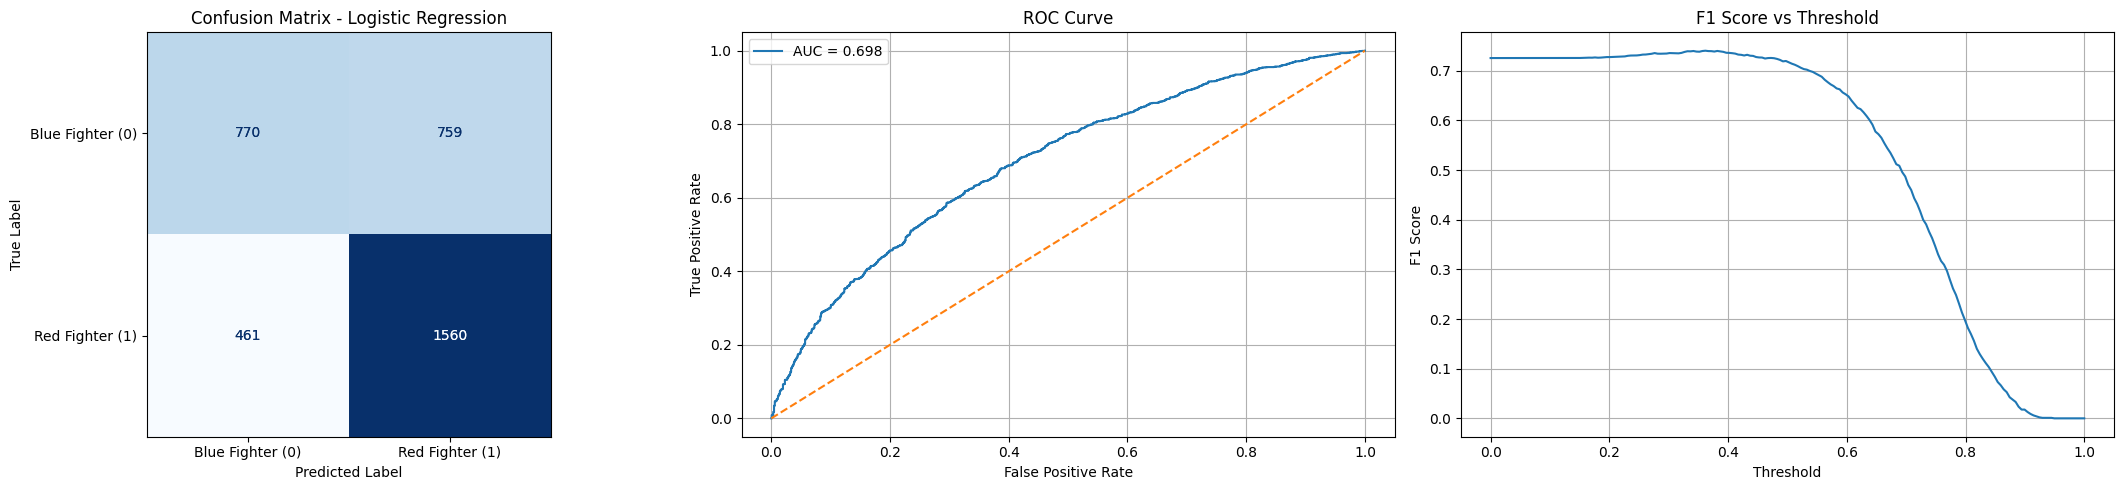

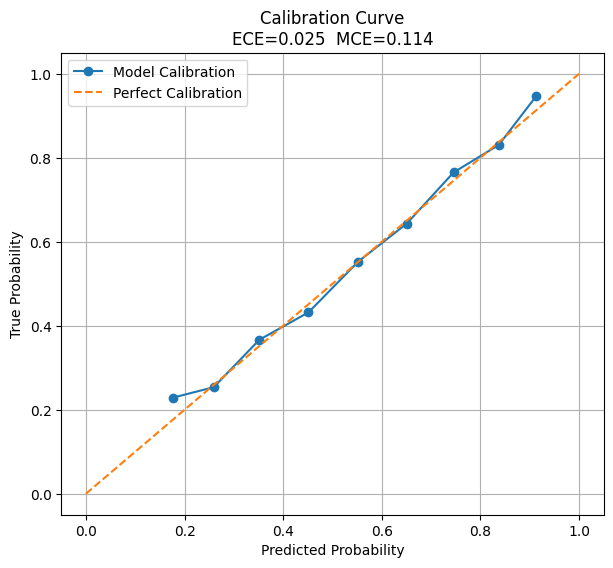

In [ ]:

results_open = run_logit_model(
    X_train, y_train,
    X_test, y_test,
    cov_type="HC3",
    reg=True,
    alpha=1.35,
    L1_wt=0.25
)


model_open = results_open['model']
model_open.save("C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\logit_model_open.pkl")

y_pred = results_open["test_pred_class"]
red_probs = results_open["test_pred_proba"]
blue_probs = 1 - red_probs

probs_2d_test = np.column_stack((1- results_open["test_pred_proba"], results_open["test_pred_proba"]))
probs_2d_train = np.column_stack((1 - results_open["train_pred_proba"], results_open["train_pred_proba"]))

plot_model_metrics(y_train, results_open["train_pred_class"], results_open["train_pred_proba"])
expected_calibration_error(y_train, results_open["train_pred_proba"], n_bins=20)

df_results_train_open = save_results(df_train, probs_2d_train, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open.csv')
df_results_test_open = save_results(df_test, probs_2d_test, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')



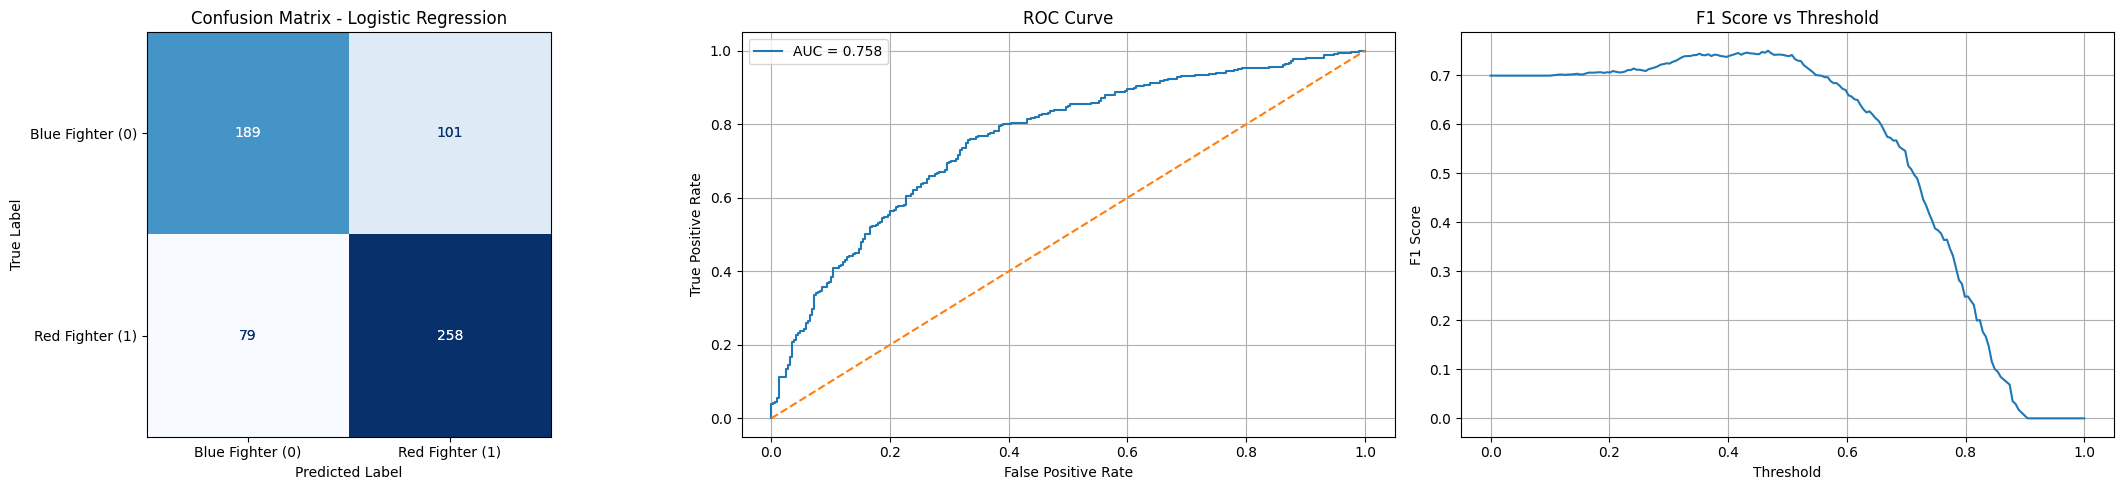

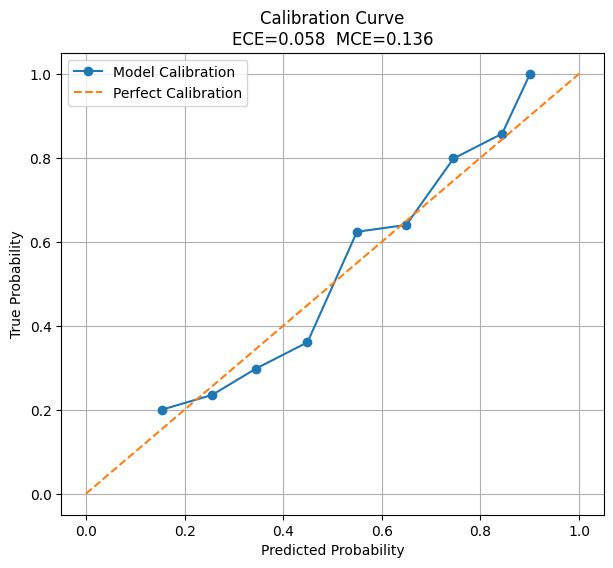

In [226]:
plot_model_metrics(y_test, y_pred, red_probs)
expected_calibration_error(y_test, red_probs, n_bins=20)

In [29]:
train_red_is_fav = (X_train['proba_fair_open_diff'] > 0).astype(int)
test_red_is_fav = (X_test['proba_fair_open_diff'] > 0).astype(int)

print(train_red_is_fav.value_counts())
print(test_red_is_fav.value_counts())


proba_fair_open_diff
1    2236
0    1861
Name: count, dtype: int64
proba_fair_open_diff
0    381
1    342
Name: count, dtype: int64


In [30]:

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-02-26.csv'
df_model = pd.read_csv(fp)

non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'performance_bonus_winner', 'fight_otn_bonus'
] 


selected_feats = [
                  'proba_fair_close1_diff', 'proba_fair_open_diff', 'reach_diff', 
                  'td_landed_total_diff', 'ratio_control_diff', 'sig_str_absorbed_total_diff', 'sig_str_landed_pm_diff', 
                  'sig_str_defense_pct_diff', 'td_attempted_pm_diff',
                  'lose_streak_diff', 'win_pct_diff', 'kd_pm_diff', 'win_streak_diff', 'ko_wins_diff', 'ko_losses_diff', 
                  'elo_red', 'elo_blue', 'age_red', 'age_blue'                  
                  ]


y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_close = builder.prepare_train_test(selected_feats, clustering=None)


joblib.dump(scaler_close, fr"C:\Users\jcmar\my_files\SportsBetting\data\saved_models\scaler_close1.pkl")


Filtered: kept 6673 rows from 2010-02-26 onward.
PREPARE SHAPE: (4909, 290)
MODEL SHAPE: (4820, 290)
Categorical columns: []
Numerical columns: ['proba_fair_close1_diff', 'proba_fair_open_diff', 'reach_diff', 'td_landed_total_diff', 'ratio_control_diff', 'sig_str_absorbed_total_diff', 'sig_str_landed_pm_diff', 'sig_str_defense_pct_diff', 'td_attempted_pm_diff', 'lose_streak_diff', 'win_pct_diff', 'kd_pm_diff', 'win_streak_diff', 'ko_wins_diff', 'ko_losses_diff', 'elo_red', 'elo_blue', 'age_red', 'age_blue']


['C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\scaler_close1.pkl']

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6161991576607735
            Iterations: 74
            Function evaluations: 74
            Gradient evaluations: 74
                        feature       VIF
0        proba_fair_close1_diff  5.086992
1                      elo_blue  5.085666
2                       elo_red  4.947302
3          proba_fair_open_diff  4.586922
4   sig_str_absorbed_total_diff  2.102784
5          td_landed_total_diff  1.865162
6                  win_pct_diff  1.734533
7                  ko_wins_diff  1.500525
8          td_attempted_pm_diff  1.491116
9               win_streak_diff  1.453341
10               ko_losses_diff  1.402218
11             lose_streak_diff  1.396109
12                      age_red  1.375205
13       sig_str_landed_pm_diff  1.235744
14                     age_blue  1.215246
15                   kd_pm_diff  1.156040
16                   reach_diff  1.056078
17     sig_str_defense_pct_diff  1

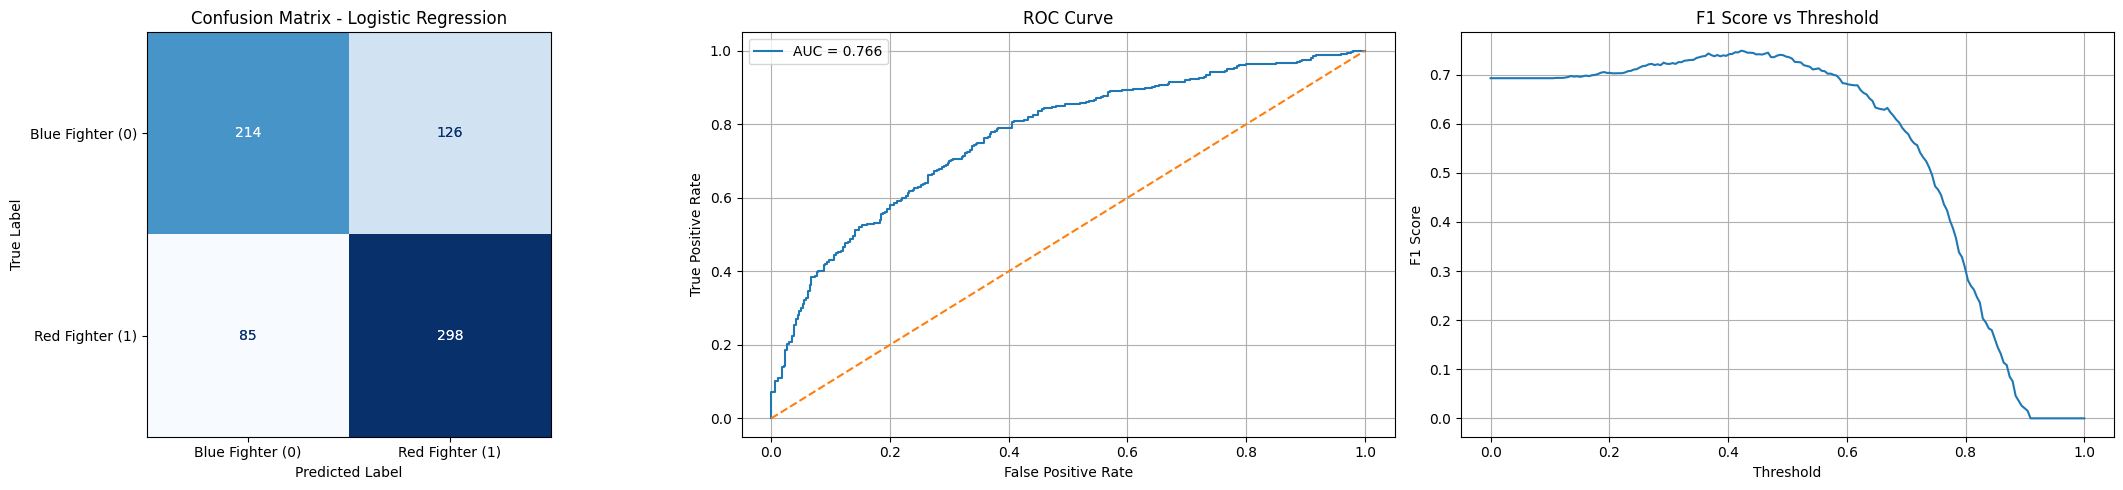

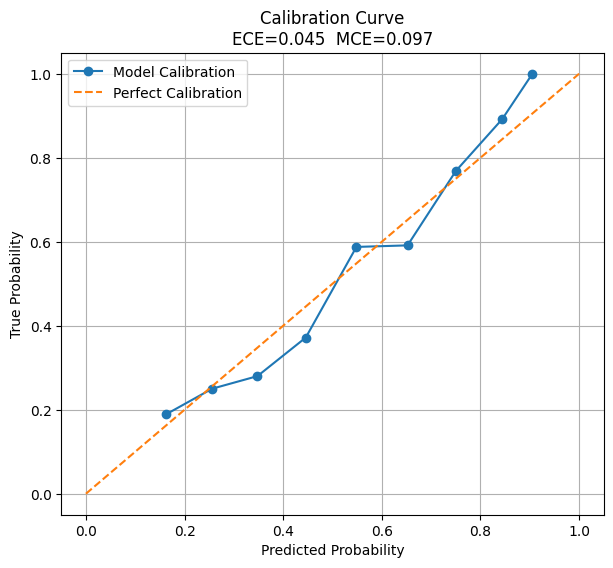

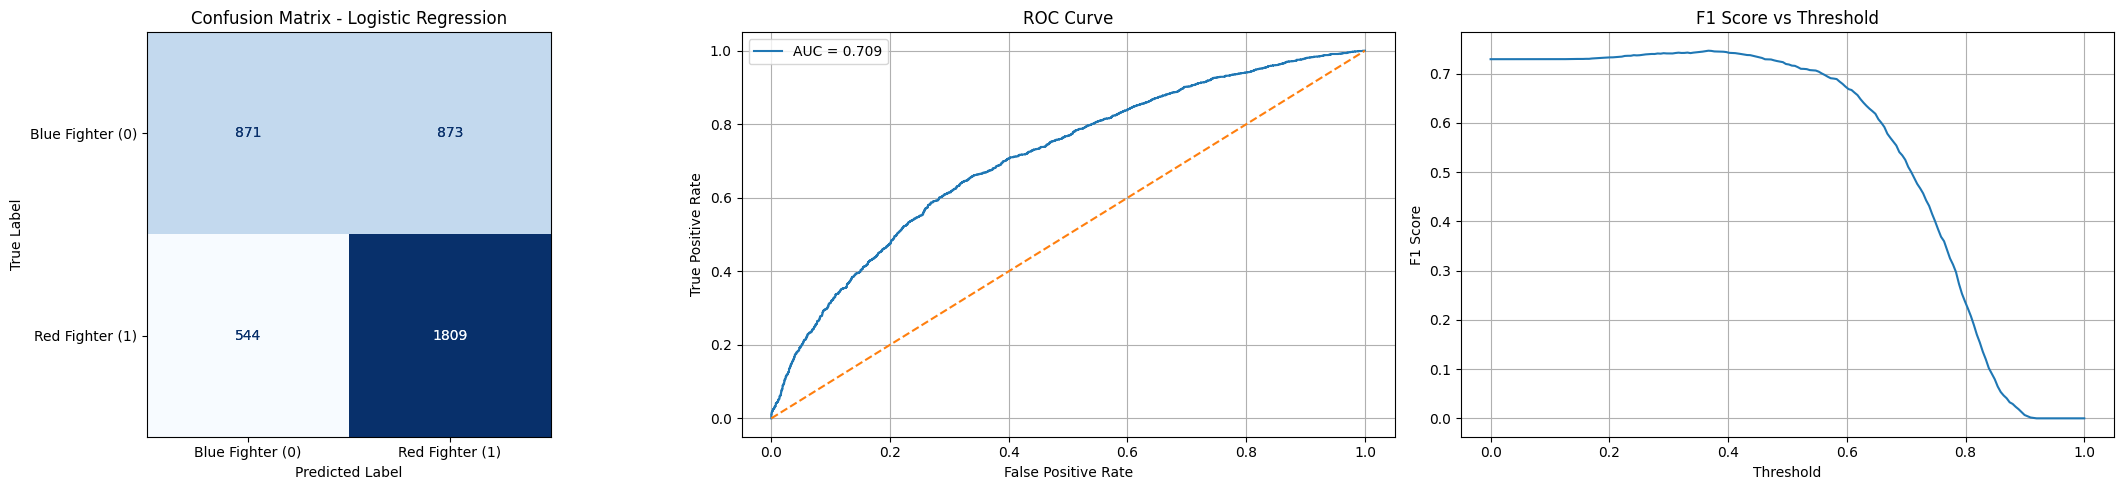

In [31]:
results_close = run_logit_model(
    X_train, y_train,
    X_test, y_test,
    cov_type="HC3",
    reg=True,
    alpha=3.5,
    L1_wt=0.2
)

model_close = results_close['model']
model_close.save("C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\logit_model_close1.pkl")

y_pred = results_close["test_pred_class"]
red_probs = results_close["test_pred_proba"]
blue_probs = 1 - red_probs
probs_2d_test = np.column_stack((blue_probs, red_probs))

df_test_results_close1 = save_results(df_test, probs_2d_test, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')
plot_model_metrics(y_test, y_pred, red_probs)
expected_calibration_error(y_test, red_probs, n_bins=20)


probs_2d_train = np.column_stack((1 - results_close["train_pred_proba"], results_close["train_pred_proba"]))
df_train_results = save_results(df_train, probs_2d_train, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close1.csv')

y_pred = results_close["train_pred_class"]
red_probs = results_close["train_pred_proba"]
plot_model_metrics(y_train, y_pred, red_probs)

In [32]:

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-01-18.csv'
df_model = pd.read_csv(fp)

non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'performance_bonus_winner', 'fight_otn_bonus'
] 


selected_feats = [
                  'proba_fair_close2_diff', 'proba_fair_open_diff', 'reach_diff', 
                  'td_landed_total_diff', 'ratio_control_diff', 'sig_str_absorbed_total_diff', 'sig_str_landed_pm_diff', 
                  'sig_str_defense_pct_diff', 'td_attempted_pm_diff',
                  'win_pct_diff', 
                  'elo_red', 'elo_blue', 'age_red', 'age_blue'
                  ]


y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_close = builder.prepare_train_test(selected_feats, clustering=None)


joblib.dump(scaler_close, fr"C:\Users\jcmar\my_files\SportsBetting\data\saved_models\scaler_close2.pkl")


Filtered: kept 6616 rows from 2010-02-26 onward.
PREPARE SHAPE: (4863, 290)
MODEL SHAPE: (4775, 290)
Categorical columns: []
Numerical columns: ['proba_fair_close2_diff', 'proba_fair_open_diff', 'reach_diff', 'td_landed_total_diff', 'ratio_control_diff', 'sig_str_absorbed_total_diff', 'sig_str_landed_pm_diff', 'sig_str_defense_pct_diff', 'td_attempted_pm_diff', 'win_pct_diff', 'elo_red', 'elo_blue', 'age_red', 'age_blue']


['C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\scaler_close2.pkl']

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.617351603370482
            Iterations: 63
            Function evaluations: 63
            Gradient evaluations: 63
                        feature       VIF
0        proba_fair_close2_diff  5.099614
1          proba_fair_open_diff  4.626942
2                      elo_blue  4.117595
3                       elo_red  3.939849
4          td_landed_total_diff  1.829903
5                  win_pct_diff  1.703805
6   sig_str_absorbed_total_diff  1.598189
7          td_attempted_pm_diff  1.465449
8                       age_red  1.346932
9                      age_blue  1.209593
10       sig_str_landed_pm_diff  1.139016
11                   reach_diff  1.045666
12     sig_str_defense_pct_diff  1.025211
13           ratio_control_diff  1.014013
                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                 4058
Mod

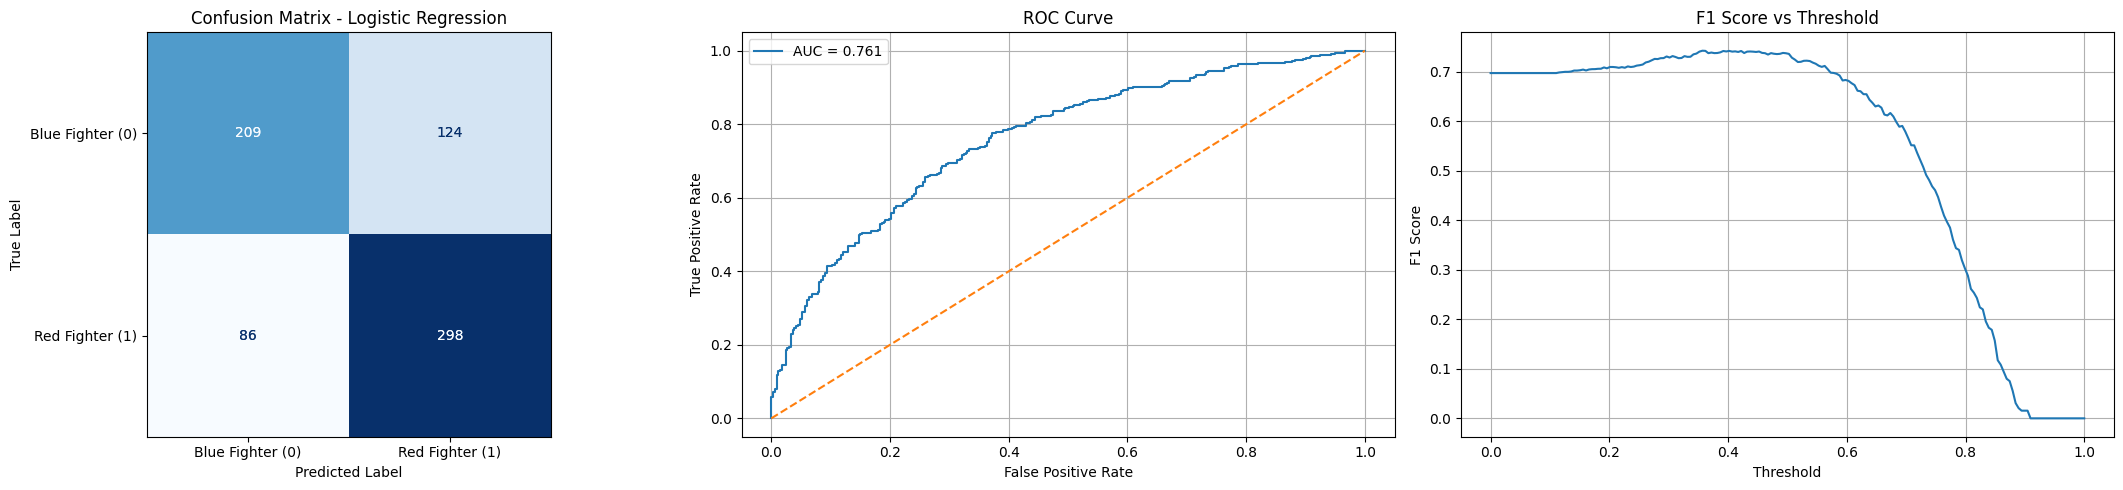

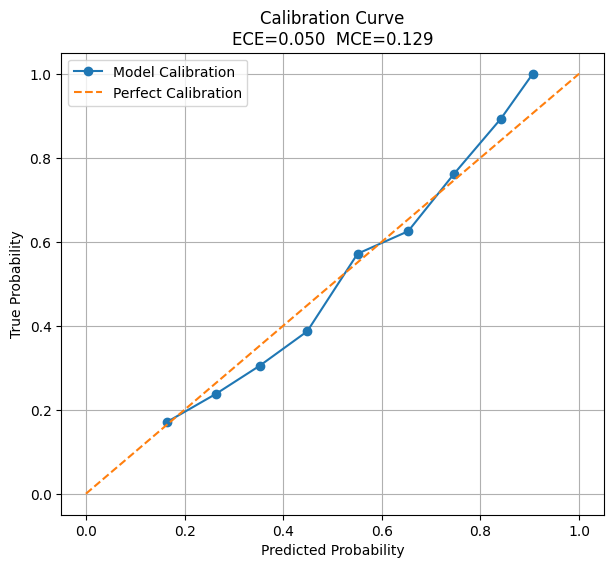

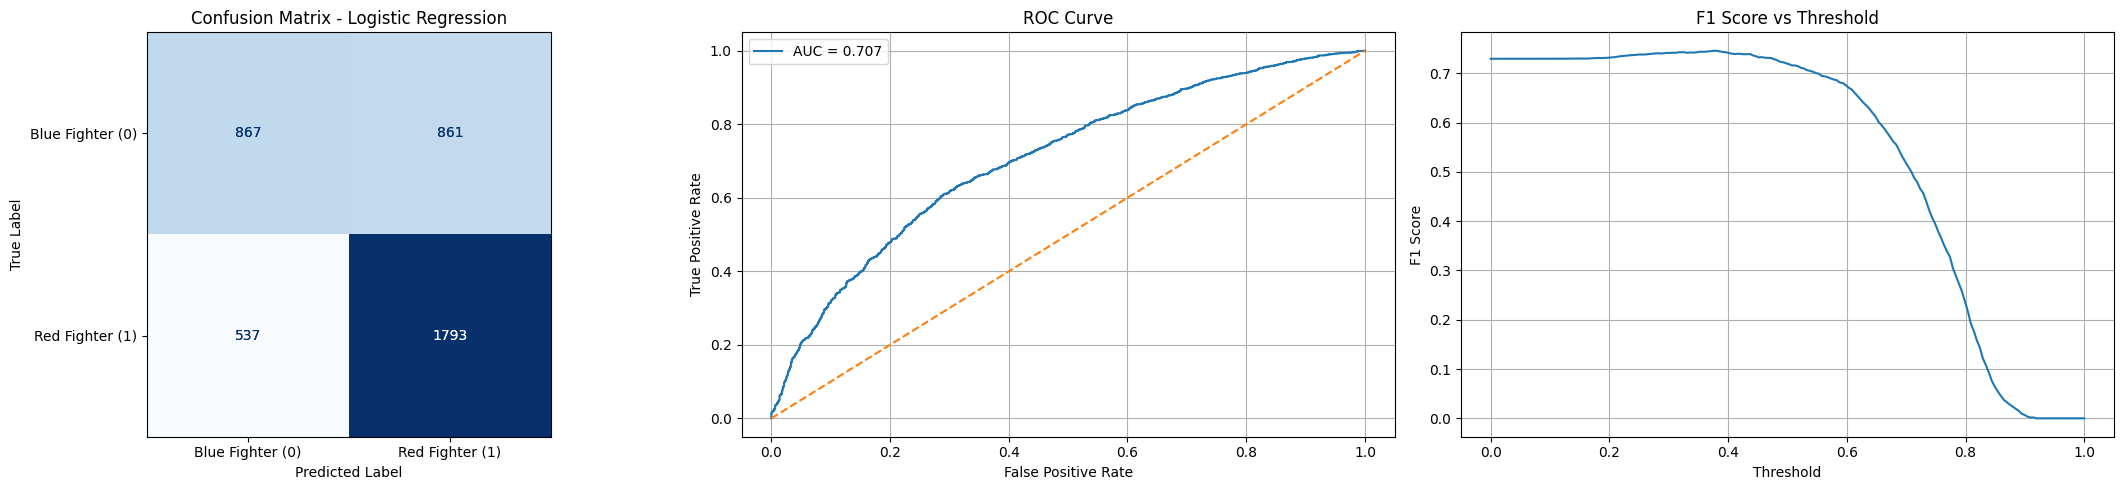

In [33]:

results_close2 = run_logit_model(
    X_train, y_train,
    X_test, y_test,
    cov_type="HC3",
    reg=True,
    alpha=3.5,
    L1_wt=0.8
)


model_close = results_close2['model']
model_close.save("C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\logit_model_close2.pkl")

y_pred = results_close2["test_pred_class"]
red_probs = results_close2["test_pred_proba"]
blue_probs = 1 - red_probs
probs_2d_test = np.column_stack((blue_probs, red_probs))

df_test_results_close2 = save_results(df_test, probs_2d_test, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')
plot_model_metrics(y_test, y_pred, red_probs)
expected_calibration_error(y_test, red_probs, n_bins=20)

probs_2d_train = np.column_stack((1 - results_close2["train_pred_proba"], results_close2["train_pred_proba"]))
df_train_results = save_results(df_train, probs_2d_train, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close2.csv')

y_pred = results_close2["train_pred_class"]
red_probs = results_close2["train_pred_proba"]
plot_model_metrics(y_train, y_pred, red_probs)